In [1]:
# Select MORE stations (for the expanded analysis on the order of thousands of stations)
## 1/2/25

In [2]:
# imports
import os
import glob
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box
from math import radians, cos, sin, asin, sqrt

/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [3]:
# interactive plotting stuff 
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib import rcParams
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

#import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6
#%config InlineBackend.figure_format = 'retina'

import cartopy
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

In [4]:
df = pd.read_csv('/home/nsiegert/projects/coastal_sst/data/hadisd_station_preppedmetadata_v341_202401p_1_6_25.csv')
df

,Unnamed: 0,STAID,STANAME,LAT,LON,ELEV,START,END,DIST2COAST,PCTREPORTING,max_pctmissing_month
0,0,010010-99999,JAN MAYEN(NOR-NAVY),70.933,-8.667,9.0,1931-01-01,2024-02-02,1.243704,82.24,41.827957
1,1,010014-99999,SORSTOKKEN,59.792,5.341,48.8,1986-11-20,2024-02-02,1.377415,82.28,26.021505
2,2,010030-99999,HORNSUND,77.000,15.500,12.0,1985-06-01,2024-02-02,3.972891,59.73,77.311828
3,3,010070-99999,NY-ALESUND,78.917,11.933,7.7,1973-01-06,2024-02-02,2.966854,52.00,85.483871
4,4,010080-99999,LONGYEAR,78.246,15.466,26.8,1975-09-29,2024-02-02,1.376450,57.09,80.860215
...,...,...,...,...,...,...,...,...,...,...,...
2533,9718,994570-99999,SAND KEY FL,24.460,-81.880,0.0,1994-10-07,2024-02-02,11.317621,NaN,NaN
2534,9769,999999-12946,CORPUS CHRISTI CABANISS NAAS,27.700,-97.433,9.1,1949-02-01,2021-09-05,8.608142,96.52,3.888889
2535,9776,999999-13752,U.S. NAVAL ACADEMY,38.991,-76.489,1.8,1945-03-01,2024-02-03,0.554924,51.09,3.763441
2536,9838,999999-40504,WEATHER SERVICE BUILDING,6.967,158.217,36.6,1953-01-01,2024-02-03,0.443097,51.57,0.000000


In [5]:
# select 25km within coast
distmask = (df.DIST2COAST < 25)

In [6]:
fail75mask = df.max_pctmissing_month < 25
fail80mask = df.max_pctmissing_month < 20
fail90mask = df.max_pctmissing_month < 10

In [7]:
df_trim1 = df[(distmask * fail75mask)]
df_trim2 = df[(distmask * fail80mask)]
df_trim3 = df[(distmask * fail90mask)]

In [8]:
pctreporting_mask = df.PCTREPORTING > 80
df_trim4 = df[(distmask * fail80mask * pctreporting_mask)]
df_trim5 = df[(distmask * fail90mask * pctreporting_mask)]
df_trim6 = df[(distmask * pctreporting_mask)]

In [9]:
gdf1 = gpd.GeoDataFrame(df_trim1, geometry=gpd.points_from_xy(x=df_trim1.LON, y=df_trim1.LAT))
gdf2 = gpd.GeoDataFrame(df_trim2, geometry=gpd.points_from_xy(x=df_trim2.LON, y=df_trim2.LAT))
gdf3 = gpd.GeoDataFrame(df_trim3, geometry=gpd.points_from_xy(x=df_trim3.LON, y=df_trim3.LAT))
gdf4 = gpd.GeoDataFrame(df_trim4, geometry=gpd.points_from_xy(x=df_trim4.LON, y=df_trim4.LAT))
gdf5 = gpd.GeoDataFrame(df_trim5, geometry=gpd.points_from_xy(x=df_trim5.LON, y=df_trim5.LAT))
gdf6 = gpd.GeoDataFrame(df_trim6, geometry=gpd.points_from_xy(x=df_trim6.LON, y=df_trim6.LAT))

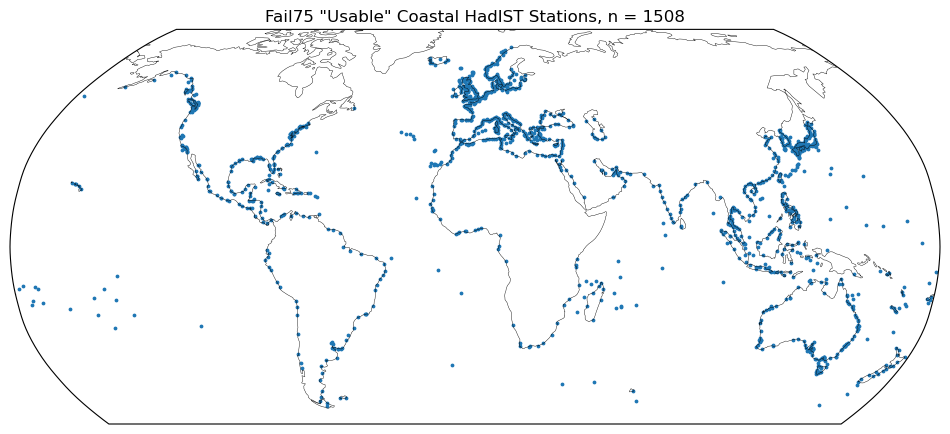

In [10]:
fig, ax = plt.subplots(subplot_kw={'projection':ccrs.Robinson()})

gdf1.plot(ax=ax, transform=ccrs.PlateCarree(), markersize=3)

ax.coastlines(lw=0.3)

ax.set(title='Fail75 "Usable" Coastal HadIST Stations, n = {}'.format(len(gdf1)))

plt.show()

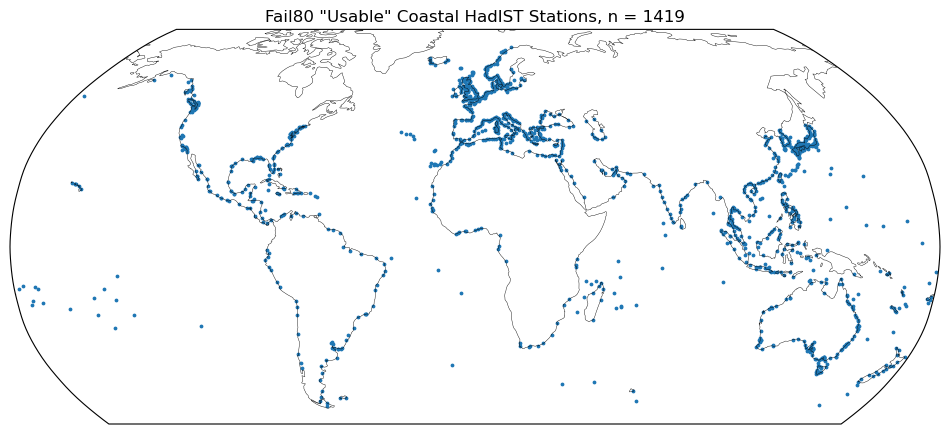

In [11]:
fig, ax = plt.subplots(subplot_kw={'projection':ccrs.Robinson()})

gdf2.plot(ax=ax, transform=ccrs.PlateCarree(), markersize=3)

ax.coastlines(lw=0.3)

ax.set(title='Fail80 "Usable" Coastal HadIST Stations, n = {}'.format(len(gdf2)))

plt.show()

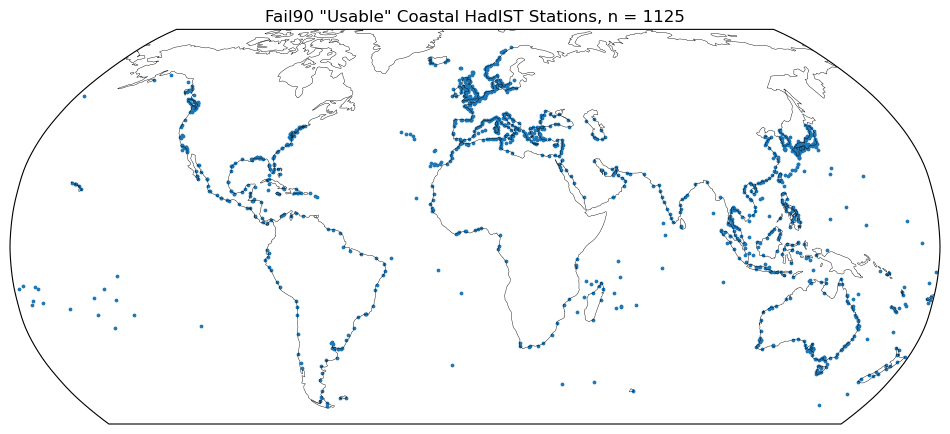

In [12]:
fig, ax = plt.subplots(subplot_kw={'projection':ccrs.Robinson()})

gdf4.plot(ax=ax, transform=ccrs.PlateCarree(), markersize=3)

ax.coastlines(lw=0.3)

ax.set(title='Fail90 "Usable" Coastal HadIST Stations, n = {}'.format(len(gdf3)))

plt.show()

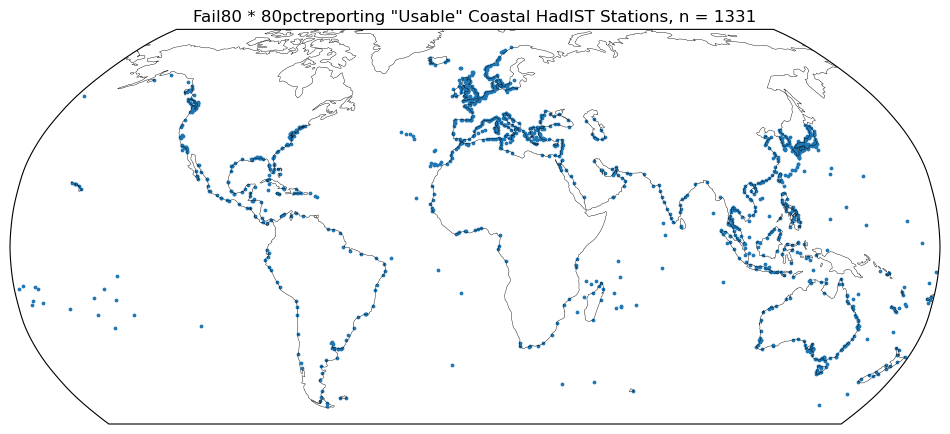

In [13]:
fig, ax = plt.subplots(subplot_kw={'projection':ccrs.Robinson()})

gdf4.plot(ax=ax, transform=ccrs.PlateCarree(), markersize=3)

ax.coastlines(lw=0.3)

ax.set(title='Fail80 * 80pctreporting "Usable" Coastal HadIST Stations, n = {}'.format(len(gdf4)))

plt.show()

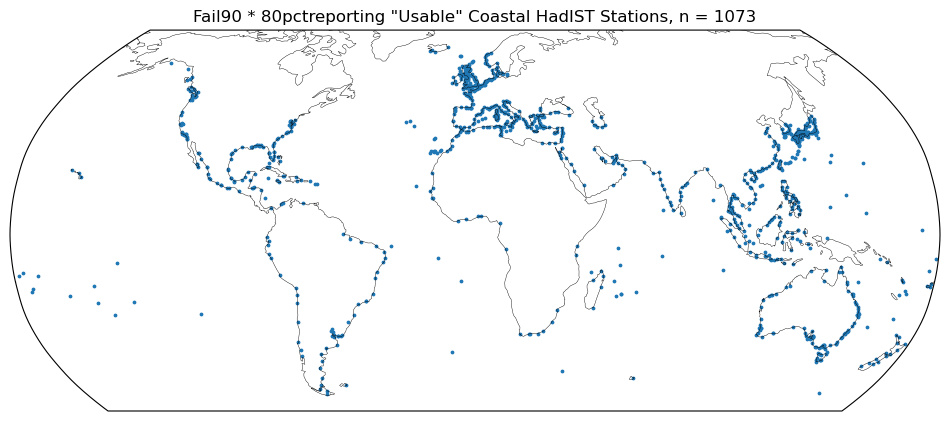

In [14]:
fig, ax = plt.subplots(subplot_kw={'projection':ccrs.Robinson()})

gdf5.plot(ax=ax, transform=ccrs.PlateCarree(), markersize=3)

ax.coastlines(lw=0.3)

ax.set(title='Fail90 * 80pctreporting "Usable" Coastal HadIST Stations, n = {}'.format(len(gdf5)))

plt.show()

In [15]:
# will need to manually exclude inland seas. caspian sea and black sea for example. 

In [16]:
df_dist = df[distmask]
gdf_dist = gpd.GeoDataFrame(df_dist, geometry=gpd.points_from_xy(x=df_dist.LON, y=df_dist.LAT))

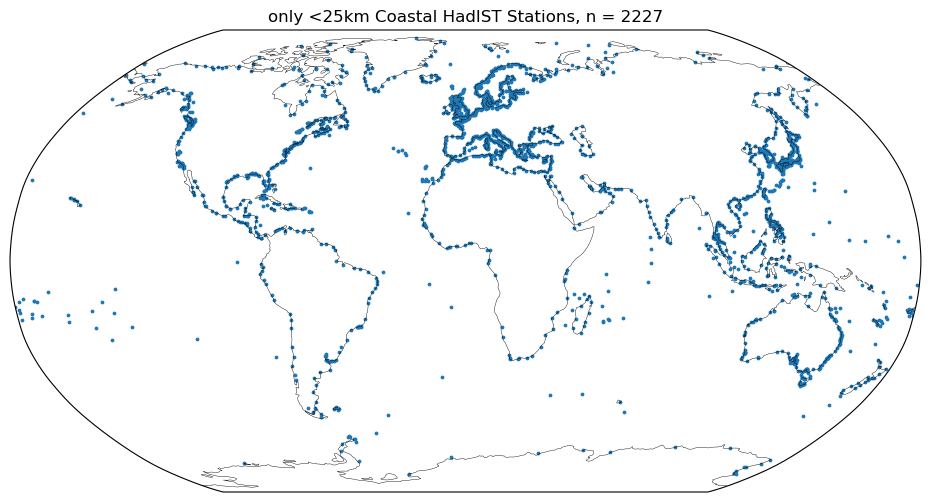

In [17]:
fig, ax = plt.subplots(subplot_kw={'projection':ccrs.Robinson()})

gdf_dist.plot(ax=ax, transform=ccrs.PlateCarree(), markersize=3)

ax.coastlines(lw=0.3)

ax.set(title='only <25km Coastal HadIST Stations, n = {}'.format(len(gdf_dist)))

plt.show()

In [18]:
# plot: 
# stations that I lose when I impose 80% reporting of data since 1990
# stations that I lose when I impose fail75, fail80, fail90

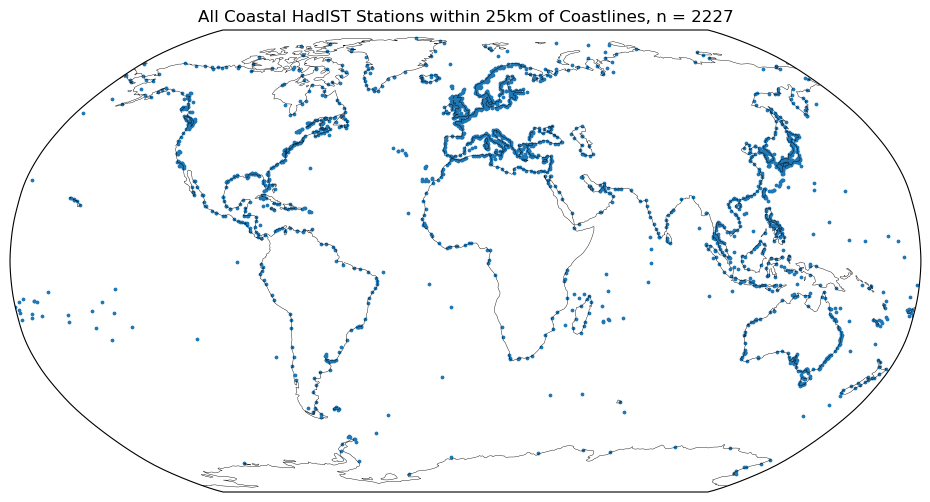

In [19]:
fig, ax = plt.subplots(subplot_kw={'projection':ccrs.Robinson()})

gdf_dist.plot(ax=ax, transform=ccrs.PlateCarree(), markersize=3)

ax.coastlines(lw=0.3)

ax.set(title='All Coastal HadIST Stations within 25km of Coastlines, n = {}'.format(len(gdf_dist)))

plt.show()

valid cells in blue, cells I lose in orange


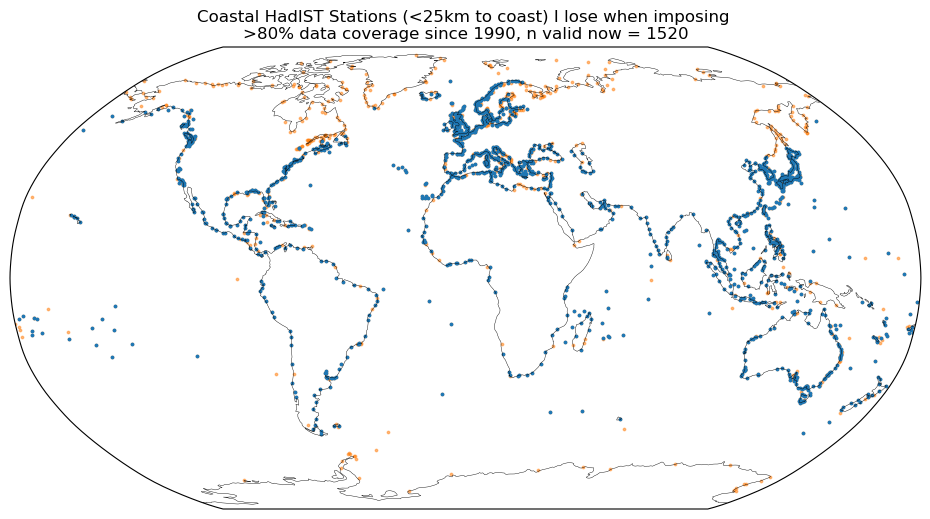

In [20]:
fig, ax = plt.subplots(subplot_kw={'projection':ccrs.Robinson()})

gdf_dist.plot(ax=ax, transform=ccrs.PlateCarree(), markersize=3, color='tab:orange', alpha=0.5)
gdf6.plot(ax=ax, transform=ccrs.PlateCarree(), markersize=3, color='tab:blue')


ax.coastlines(lw=0.3)

ax.set(title='Coastal HadIST Stations (<25km to coast) I lose when imposing \n>80% data coverage since 1990, n valid now = {}'.format(len(gdf6)))

print("valid cells in blue, cells I lose in orange")

plt.show()

valid cells in blue, cells I lose in orange

my only issue here is that I lose the WBC extension regions in both Atlantic and Pacific. What's going on with those weather stations?



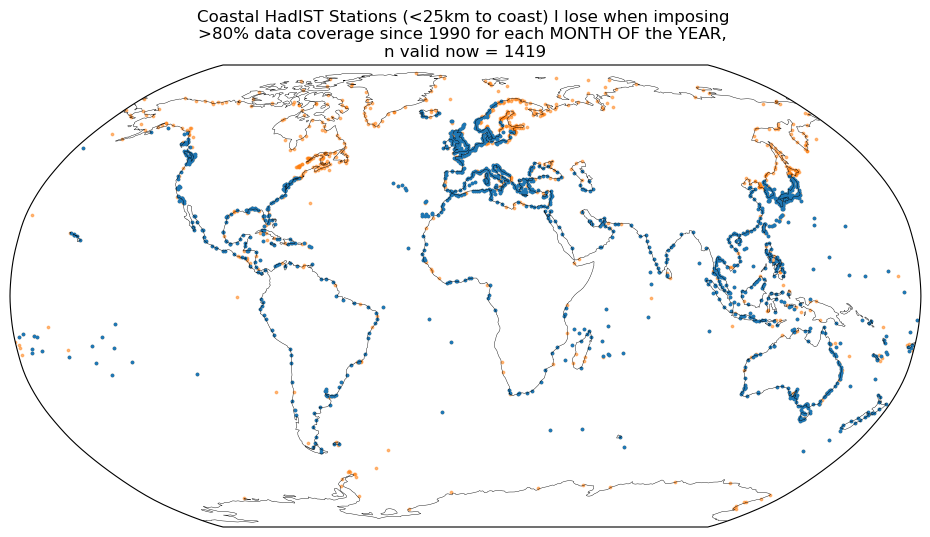

In [21]:
fig, ax = plt.subplots(subplot_kw={'projection':ccrs.Robinson()})

gdf_dist.plot(ax=ax, transform=ccrs.PlateCarree(), markersize=3, color='tab:orange', alpha=0.5)
gdf2.plot(ax=ax, transform=ccrs.PlateCarree(), markersize=3, color='tab:blue')


ax.coastlines(lw=0.3)

ax.set(title='Coastal HadIST Stations (<25km to coast) I lose when imposing \n>80% data coverage since 1990 for each MONTH OF the YEAR, \nn valid now = {}'.format(len(gdf2)))

print("valid cells in blue, cells I lose in orange")
print('')
print("my only issue here is that I lose the WBC extension regions in both Atlantic and Pacific. What's going on with those weather stations?")
print('')

plt.show()

valid cells in blue, cells I lose in orange

I lose the WBC extension regions in both Atlantic and Pacific. What's going on with those weather stations?



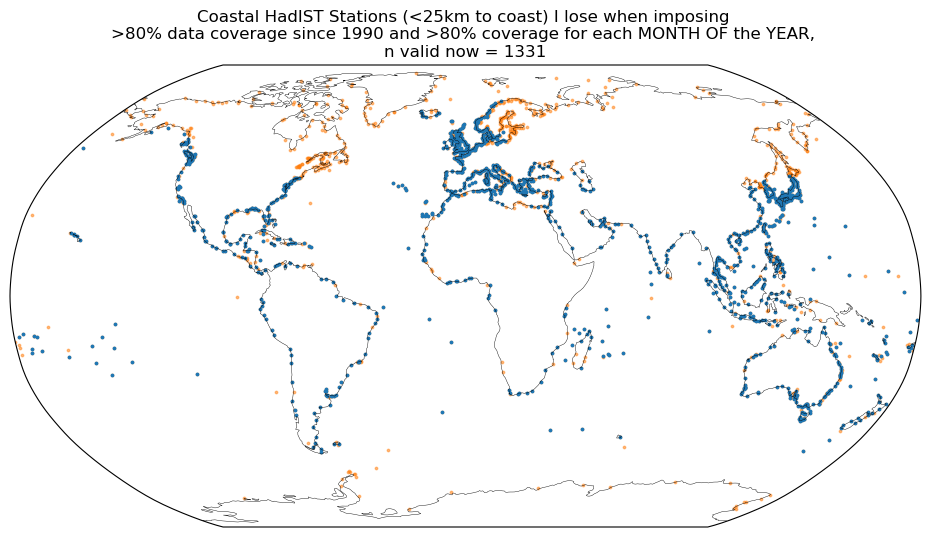

In [22]:
fig, ax = plt.subplots(subplot_kw={'projection':ccrs.Robinson()})

gdf_dist.plot(ax=ax, transform=ccrs.PlateCarree(), markersize=3, color='tab:orange', alpha=0.5)
gdf4.plot(ax=ax, transform=ccrs.PlateCarree(), markersize=3, color='tab:blue')


ax.coastlines(lw=0.3)

ax.set(title='Coastal HadIST Stations (<25km to coast) I lose when imposing \n>80% data coverage since 1990 and >80% coverage for each MONTH OF the YEAR, \nn valid now = {}'.format(len(gdf4)))

print("valid cells in blue, cells I lose in orange")
print('')
print("I lose the WBC extension regions in both Atlantic and Pacific. What's going on with those weather stations?")
print('')

plt.show()

## FOR NOW, I will to use the criteria: Station must be <25km to coastline, >80% of data reporting since 1990

In [23]:
# I may still incorporate the >80% for each month of year or at least season... don't want results to be biased by certain stations only reporting certain months...

In [24]:
# and maybe I need to figure out its percentage reporting for the warm season or something. 

In [ ]:
# I should mask out those seas also... 
# and maybe cut anything above 70 degrees either side of eq 

In [59]:
CS_latmask = (df_trim6.LAT >= 35.5) * (df_trim6.LAT <= 48)
CS_lonmask = (df_trim6.LON >= 45) * (df_trim6.LON <= 56)
CS_mask = (CS_latmask * CS_lonmask)

In [60]:
BS_latmask = (df_trim6.LAT >= 41.1) * (df_trim6.LAT <= 47.2)
BS_lonmask = (df_trim6.LON >= 27.2) * (df_trim6.LON <= 42)

BS_latmask2 = (df_trim6.LAT >= 40.) * (df_trim6.LAT <= 44)
BS_lonmask2 = (df_trim6.LON >= 35) * (df_trim6.LON <= 42)
BS_mask = (BS_latmask * BS_lonmask) + (BS_latmask2 * BS_lonmask2)

In [61]:
gdfCS = gpd.GeoDataFrame(df_trim6[CS_mask], geometry=gpd.points_from_xy(x=df_trim6[CS_mask].LON, y=df_trim6[CS_mask].LAT))
gdfBS = gpd.GeoDataFrame(df_trim6[BS_mask], geometry=gpd.points_from_xy(x=df_trim6[BS_mask].LON, y=df_trim6[BS_mask].LAT))

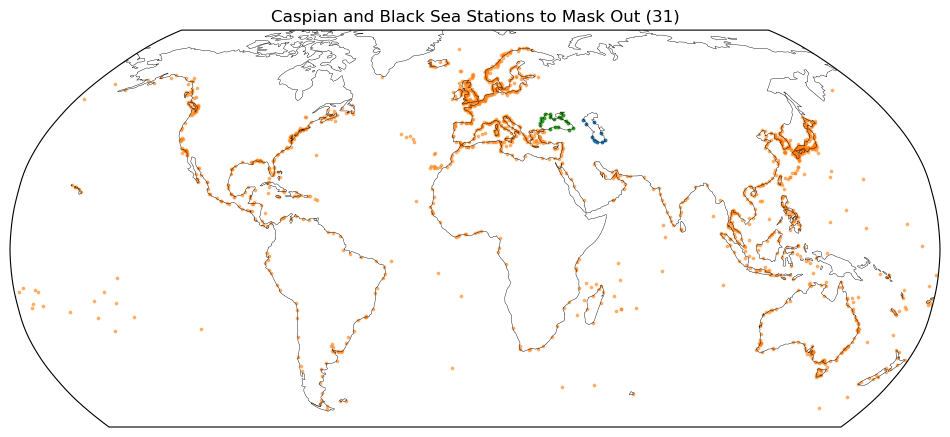

In [62]:
fig, ax = plt.subplots(subplot_kw={'projection':ccrs.Robinson()})

gdf6.plot(ax=ax, transform=ccrs.PlateCarree(), markersize=3, color='tab:orange', alpha=0.5)
gdfCS.plot(ax=ax, transform=ccrs.PlateCarree(), markersize=3, color='tab:blue')
gdfBS.plot(ax=ax, transform=ccrs.PlateCarree(), markersize=3, color='tab:green')


ax.coastlines(lw=0.3)

ax.set(title='Caspian and Black Sea Stations to Mask Out ({})'.format(len(gdfCS) + len(gdfBS)))


plt.show()

In [ ]:
# I should mask out those seas also... 
# and maybe cut anything above 70 degrees either side of eq 

In [63]:
highlatmask = df_trim6.LAT <= 68.5

In [64]:
# combine all masks
all_masks = (np.logical_not(CS_mask) * np.logical_not(BS_mask) * highlatmask)

In [65]:
gdfall = gpd.GeoDataFrame(df_trim6[all_masks], geometry=gpd.points_from_xy(x=df_trim6[all_masks].LON, y=df_trim6[all_masks].LAT))

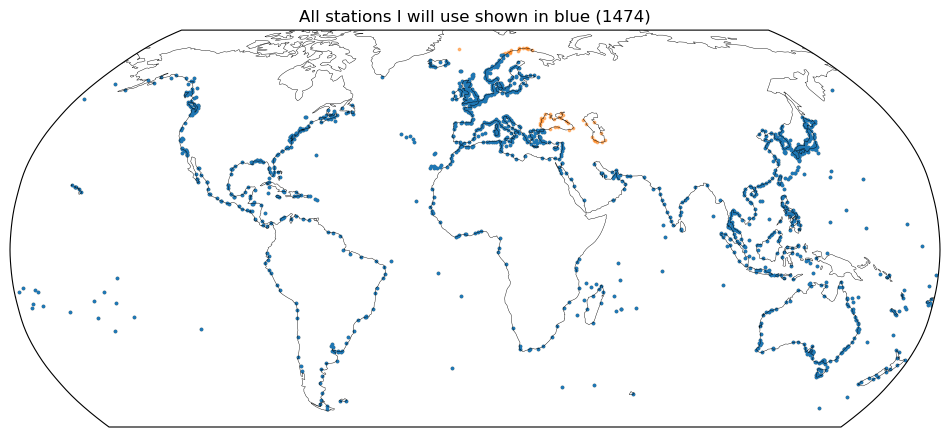

In [67]:
fig, ax = plt.subplots(subplot_kw={'projection':ccrs.Robinson()})

gdf6.plot(ax=ax, transform=ccrs.PlateCarree(), markersize=3, color='tab:orange', alpha=0.5)
gdfall.plot(ax=ax, transform=ccrs.PlateCarree(), markersize=3, color='tab:blue')

ax.coastlines(lw=0.3)

ax.set(title='All stations I will use shown in blue ({})'.format(len(gdfall)))


plt.show()

In [68]:
# save:
dfsave = df_trim6.drop(labels='Unnamed: 0', axis=1)
dfsave = dfsave[all_masks]
dfsave.to_csv('/home/nsiegert/projects/coastal_sst/data/hadisd_stations_using_Expanded.csv')